# Figure panels: reconstructions of the 10 degree mosaicity sample

The panels of the article's figure for this sample, saved as separate transparent PNGs to
`processed/visualization/domains_mosaicity_10p0deg/` for assembly in Inkscape:

* IPF-Z maps of the ground truth, the point-by-point (pbp) map and the texture tomography (TT)
  reconstructions with the uniform grid and the adaptive basis, with scale bars (also a version
  with the zoom window drawn as a box);
* zooms on one grain with its surroundings (the largest orange grain in the ground truth's IPF-Z
  map), for the IPF-Z maps and the misorientation maps;
* misorientation to the ground truth (full maps and zooms), with separate colorbars;
* grain boundaries (red / blue) and grain + subgrain boundaries (four colours) of each
  reconstruction together with the ground truth's, with legends;
* the IPF colour key.

All maps are compared on one grid: the reconstructions' 99 x 99 voxels, upsampled 4x by
nearest neighbour; the ground truth is interpolated from the simulation mesh at that resolution.
A TT reconstruction is shown as its weighted medoid orientation per voxel.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path

# make the repository importable, whatever the working directory is
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "simtools").is_dir())
sys.path.insert(0, str(REPO))

import os

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt
from simtools import figures, io, paths

## Parameters

In [2]:
SAMPLE = "domains_mosaicity_10p0deg"
PBP_MAP = "filtered"   # pbp map shown: "best" candidate or "filtered" (see 03_refine.ipynb)

UPSAMPLE = 4                # display grid: UPSAMPLE x 99 pixels per side
TOP_K = 24                  # TT: orientations per voxel entering the weighted medoid
MISORI_VMAX = 40.0          # deg, top of the misorientation colour scale (log scale)
GB_THRESHOLD = 4.0          # deg, KAM at or above this: grain boundary
SUBGRAIN_THRESHOLD = 0.5    # deg, KAM at or above this: subgrain boundary
GT_MEDIAN_KERNEL = 5        # quaternion median filter of the ground truth before finding boundaries
SCALEBAR_UM = 2.0           # scale bar on the full maps
ZOOM_MARGIN = 0.1           # zoom window: the grain's bounding box grown by this fraction on every side

OUT = os.path.join(paths.PROCESS, "visualization", SAMPLE)
os.makedirs(OUT, exist_ok=True)

# translation step = voxel size of the reconstructions (the simulation works in micrometres)
with h5py.File(io.scan_files(SAMPLE)[0]) as f0, h5py.File(io.scan_files(SAMPLE)[1]) as f1:
    step_um = float(f1[io.scan_key(f1)]["eiger/frames/y"][0] - f0[io.scan_key(f0)]["eiger/frames/y"][0])
pixel_um = step_um / UPSAMPLE
N = 99 * UPSAMPLE
print(f"voxel {step_um:.4f} um, display pixel {pixel_um:.4f} um, grid {N} x {N}")

voxel 0.1020 um, display pixel 0.0255 um, grid 396 x 396


## Ground truth
Orientations of the simulation mesh, interpolated onto the display grid (nearest neighbour; outside the sample: none).

In [3]:
gt, gt_valid = figures.ground_truth_map(SAMPLE, N, pixel_um)
gt_valid_voxels = gt_valid[::UPSAMPLE, ::UPSAMPLE]  # on the 99 x 99 reconstruction grid
print(f"ground truth: {gt_valid.sum()} pixels in the sample")

ground truth: 120098 pixels in the sample


## Reconstructions
* **pbp**: the point-by-point map saved by `adaptive_basis/<sample>/indexing/03_refine.ipynb`;
* **TT uniform / TT adaptive**: `texture_tomography/<sample>/textomo_uniform.ipynb` and
  `textomo_adaptive.ipynb`; per voxel the weighted medoid of the `TOP_K` largest coefficients
  (cached in the output folder, recomputed when a reconstruction file changes).

In [4]:
maps = {}  # name -> (orientations, valid) on the display grid

pbp = np.load(os.path.join(paths.process_dir(SAMPLE), "pbp_map.npz"))
pbp_ori = pbp[PBP_MAP][:, ::-1].astype(float)            # same orientation of the map as the ground truth
pbp_ori[np.all(pbp_ori == 0, axis=(-2, -1))] = np.nan
pbp_valid = np.isfinite(pbp_ori[..., 0, 0]) & pbp["mask"][:, ::-1]
ori, valid = figures.upsample(pbp_ori, pbp_valid, UPSAMPLE)
maps["pbp"] = (ori, valid & gt_valid)

for name in ["tt_uniform", "tt_adaptive"]:
    h5 = os.path.join(paths.process_dir(SAMPLE), f"reconstruction_{name[3:]}.h5")
    with h5py.File(h5, "r") as f:
        print(f"{name}: K = {f.attrs['K']}, sigma = {f.attrs['sigma_deg']} deg, {f.attrs['niter']} iterations")
    medoid = figures.load_tt_medoid(h5, gt_valid_voxels, os.path.join(OUT, f"medoid_{name}.npz"), top_k=TOP_K)
    ori, valid = figures.upsample(medoid, np.isfinite(medoid[..., 0, 0]), UPSAMPLE)
    maps[name] = (ori, valid & gt_valid)

tt_uniform: K = 100332, sigma = 1.3 deg, 200 iterations
  medoid from cache medoid_tt_uniform.npz
tt_adaptive: K = 3025, sigma = 0.4 deg, 2000 iterations
  medoid from cache medoid_tt_adaptive.npz


## Zoom window
A rectangle around the largest orange grain of the ground truth's IPF-Z map (found on the voxel grid; at the display resolution neighbouring orange grains touch), grown by `ZOOM_MARGIN`. The same window is used for every map.

In [5]:
gt_voxels, _ = figures.ground_truth_map(SAMPLE, 99, step_um)
grain = figures.upsample(np.zeros((99, 99, 3, 3)), figures.orange_grain(gt_voxels), UPSAMPLE)[1] & gt_valid
window = figures.zoom_window(grain, ZOOM_MARGIN)
print(f"grain: {grain.sum()} pixels; zoom window rows {window[0].start}-{window[0].stop}, columns {window[1].start}-{window[1].stop}")

grain: 7024 pixels; zoom window rows 138-258, columns 169-303


## IPF-Z maps and zooms

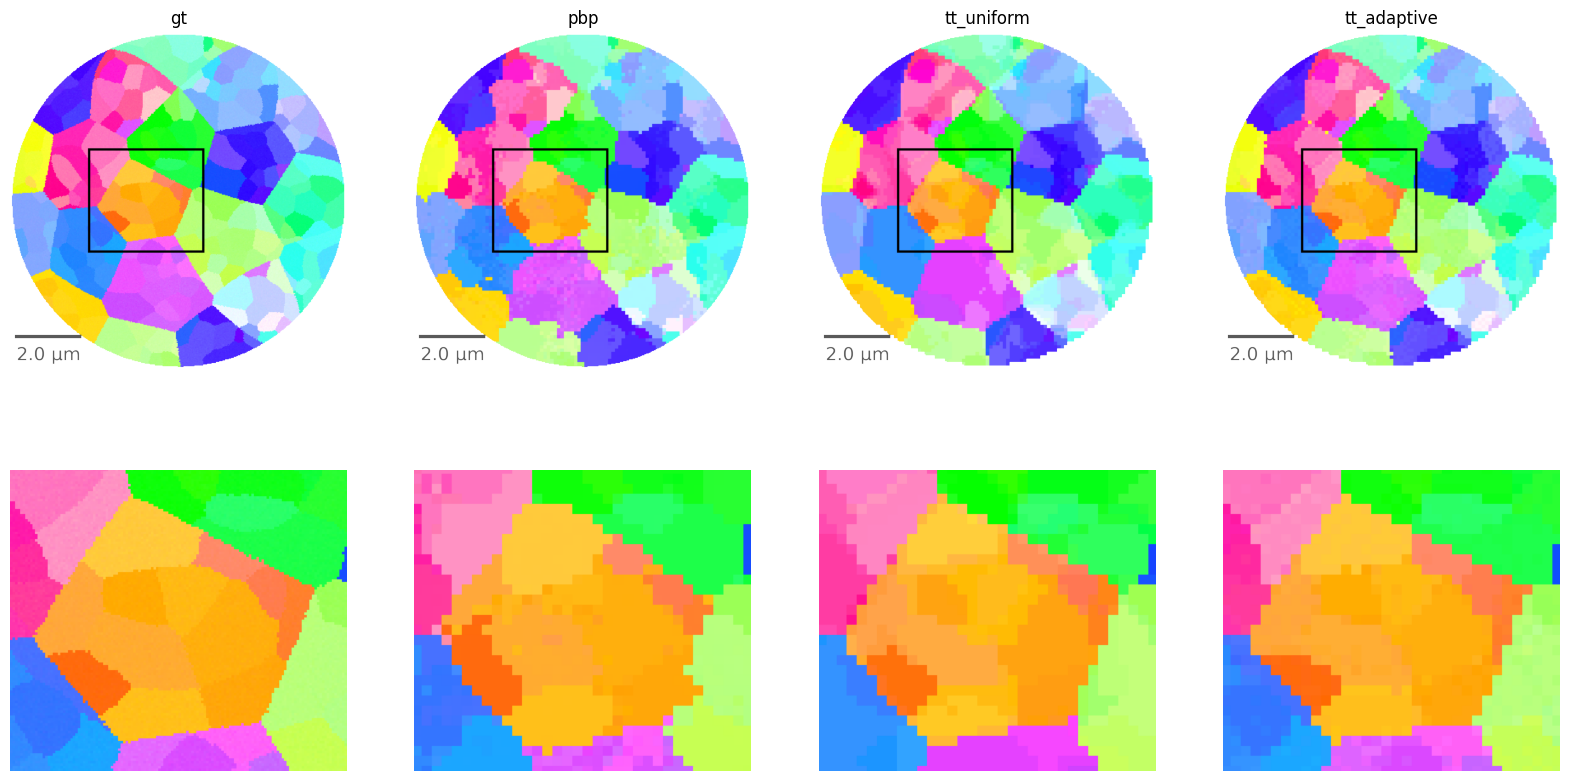

In [6]:
all_maps = {"gt": (gt, gt_valid), **maps}
for name, (ori, valid) in all_maps.items():
    figures.save_ipf(os.path.join(OUT, f"ipf_z_{name}.png"), ori, valid, pixel_um, SCALEBAR_UM)
    figures.save_ipf(os.path.join(OUT, f"ipf_z_{name}_box.png"), ori, valid, pixel_um, SCALEBAR_UM, box=window)
    figures.save_ipf(os.path.join(OUT, f"zoom_ipf_z_{name}.png"), ori, valid, pixel_um, crop=window)

names = ["gt"] + list(maps)
fig, ax = plt.subplots(2, len(names), figsize=(5 * len(names), 10))
for j, name in enumerate(names):
    ax[0, j].imshow(plt.imread(os.path.join(OUT, f"ipf_z_{name}_box.png")))
    ax[1, j].imshow(plt.imread(os.path.join(OUT, f"zoom_ipf_z_{name}.png")))
    ax[0, j].set_title(name)
for a in ax.ravel():
    a.axis("off")
plt.show()

## Misorientation to the ground truth
Colour scale: jet on log10(0.1 + angle), up to `MISORI_VMAX`; the colorbars are saved separately. Full maps and zooms (same window as above).

In [7]:
misori = {}
rows = []
for name, (ori, valid) in maps.items():
    m = figures.misorientation_map(gt, ori, valid)
    misori[name] = m
    figures.save_misorientation(os.path.join(OUT, f"misorientation_{name}.png"), m, valid, pixel_um, MISORI_VMAX, SCALEBAR_UM)
    figures.save_misorientation(os.path.join(OUT, f"zoom_misorientation_{name}.png"), m, valid, pixel_um,
                                MISORI_VMAX, crop=window)
    rows.append({"map": name, "mean (deg)": np.nanmean(m), "median (deg)": np.nanmedian(m),
                 "90th percentile (deg)": np.nanpercentile(m, 90)})
figures.save_misorientation_colorbars(OUT, MISORI_VMAX)
misori_table = pd.DataFrame(rows).round(3)
misori_table.to_csv(os.path.join(OUT, "misorientation_statistics.csv"), index=False)
misori_table

,map,mean (deg),median (deg),90th percentile (deg)
0,pbp,2.939,0.404,4.462
1,tt_uniform,2.257,1.208,2.367
2,tt_adaptive,1.463,0.388,0.874


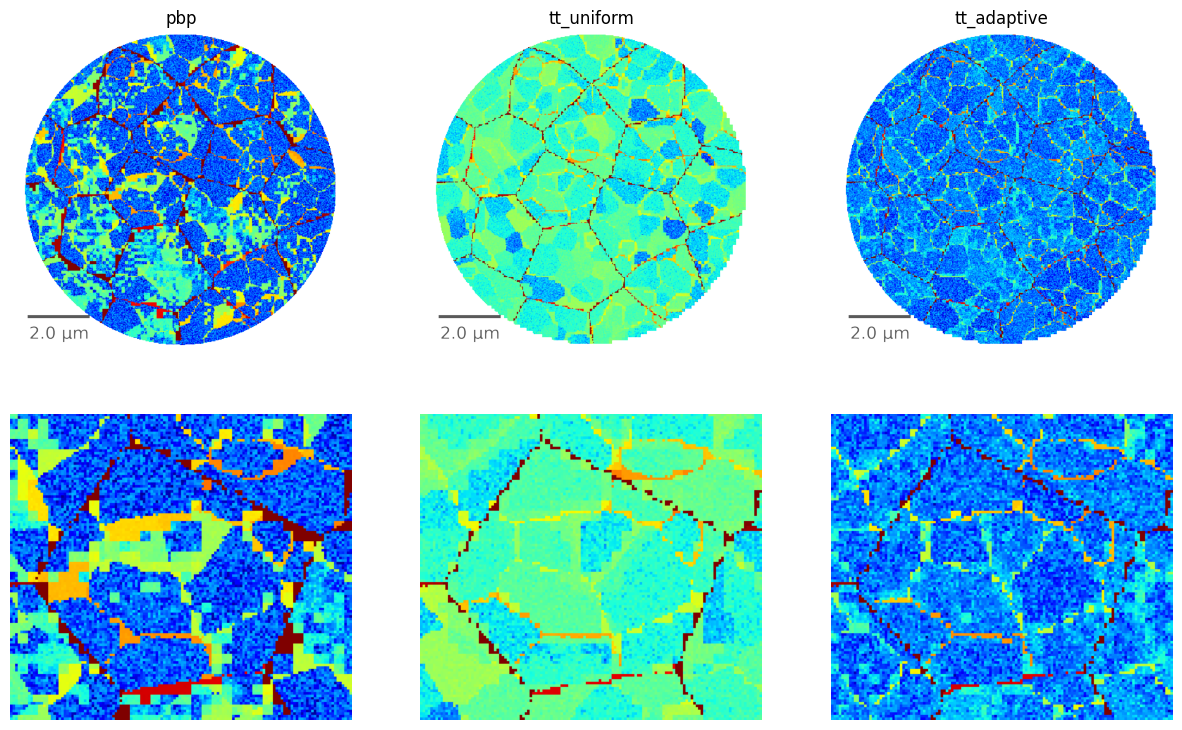

In [8]:
names = list(maps)
fig, ax = plt.subplots(2, len(names), figsize=(5 * len(names), 9))
for j, name in enumerate(names):
    ax[0, j].imshow(plt.imread(os.path.join(OUT, f"misorientation_{name}.png")))
    ax[1, j].imshow(plt.imread(os.path.join(OUT, f"zoom_misorientation_{name}.png")))
    ax[0, j].set_title(name)
for a in ax.ravel():
    a.axis("off")
plt.show()

## Grain and subgrain boundaries
Boundary pixels are those with a kernel average misorientation (to the 4 neighbours) of at least
`GB_THRESHOLD` (grain boundaries) or `SUBGRAIN_THRESHOLD` (subgrain boundaries), within the sample
eroded by one voxel. The ground truth is median-filtered first to remove the mesh noise. Each
reconstruction's boundaries are drawn together with the ground truth's, in two styles:
`boundaries_main_*` (grain boundaries only; reconstruction red, ground truth blue) and
`boundaries_main_sub_*` (grain and subgrain boundaries, four colours). The table gives the
distance from each reconstructed boundary pixel to the nearest ground-truth boundary of the same
kind (the "boundary deviation"), in micrometres: one display pixel is `pixel_um`.

In [9]:
region = figures.eroded(gt_valid, UPSAMPLE)
gt_f, gt_f_valid = figures.median_filter_orientations(gt, gt_valid, GT_MEDIAN_KERNEL)
gt_main = figures.boundaries(gt_f, gt_f_valid, region, GB_THRESHOLD)
gt_sub = figures.boundaries(gt_f, gt_f_valid, region, SUBGRAIN_THRESHOLD)
figures.save_boundaries(os.path.join(OUT, "boundaries_main_gt.png"), figures.grain_boundary_image(gt_main))
figures.save_boundaries(os.path.join(OUT, "boundaries_main_sub_gt.png"), figures.boundary_image(gt_main, gt_sub))

dist_main, dist_sub = distance_transform_edt(~gt_main), distance_transform_edt(~gt_sub)
rows = []
for name, (ori, valid) in maps.items():
    rec_main = figures.boundaries(ori, valid, region, GB_THRESHOLD)
    rec_sub = figures.boundaries(ori, valid, region, SUBGRAIN_THRESHOLD)
    figures.save_boundaries(os.path.join(OUT, f"boundaries_main_{name}.png"), figures.grain_boundary_image(gt_main, rec_main))
    figures.save_boundaries(os.path.join(OUT, f"boundaries_main_sub_{name}.png"),
                            figures.boundary_image(gt_main, gt_sub, rec_main, rec_sub))
    for kind, rec, dist, thr in [("grain", rec_main, dist_main, GB_THRESHOLD), ("subgrain", rec_sub, dist_sub, SUBGRAIN_THRESHOLD)]:
        d = dist[rec] * pixel_um
        rows.append({"map": name, "boundary": kind, "threshold (deg)": thr, "pixels": int(rec.sum()),
                     "mean deviation (um)": d.mean() if len(d) else np.nan,
                     "median deviation (um)": np.median(d) if len(d) else np.nan,
                     "mean deviation (display pixels)": d.mean() / pixel_um if len(d) else np.nan})
figures.save_boundary_legends(OUT)
boundary_table = pd.DataFrame(rows).round(4)
boundary_table.to_csv(os.path.join(OUT, "boundary_statistics.csv"), index=False)
boundary_table

,map,boundary,threshold (deg),pixels,mean deviation (um),median deviation (um),mean deviation (display pixels)
0,pbp,grain,4.0,6073,0.0502,0.0361,1.9691
1,pbp,subgrain,0.5,22040,0.0619,0.0361,2.4292
2,tt_uniform,grain,4.0,5611,0.0177,0.0255,0.6941
3,tt_uniform,subgrain,0.5,21633,0.0477,0.0255,1.8723
4,tt_adaptive,grain,4.0,5899,0.0171,0.0255,0.6693
5,tt_adaptive,subgrain,0.5,18362,0.0175,0.0255,0.6846


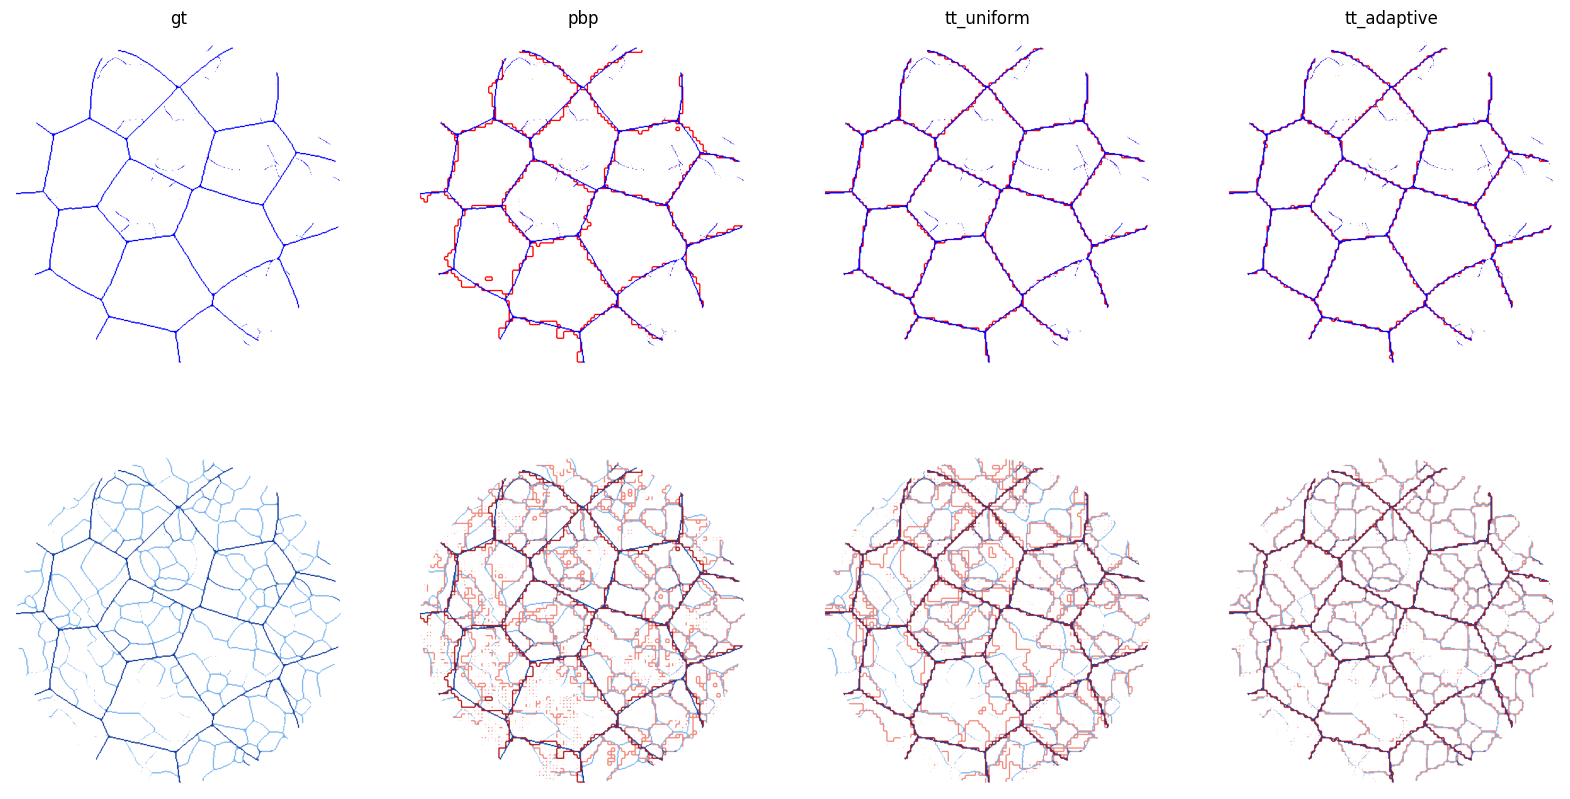

In [10]:
names = ["gt"] + list(maps)
fig, ax = plt.subplots(2, len(names), figsize=(5 * len(names), 10))
for j, name in enumerate(names):
    ax[0, j].imshow(plt.imread(os.path.join(OUT, f"boundaries_main_{name}.png")))
    ax[1, j].imshow(plt.imread(os.path.join(OUT, f"boundaries_main_sub_{name}.png")))
    ax[0, j].set_title(name)
for a in ax.ravel():
    a.axis("off")
plt.show()

## IPF colour key

In [11]:
figures.save_ipf_colorkey(os.path.join(OUT, "ipf_colorkey.png"))
print("\n".join(sorted(f for f in os.listdir(OUT) if f.endswith((".png", ".csv")))))

boundaries_main_gt.png
boundaries_main_pbp.png
boundaries_main_sub_gt.png
boundaries_main_sub_pbp.png
boundaries_main_sub_tt_adaptive.png
boundaries_main_sub_tt_uniform.png
boundaries_main_tt_adaptive.png
boundaries_main_tt_uniform.png
boundary_statistics.csv
ipf_colorkey.png
ipf_z_gt.png
ipf_z_gt_box.png
ipf_z_pbp.png
ipf_z_pbp_box.png
ipf_z_tt_adaptive.png
ipf_z_tt_adaptive_box.png
ipf_z_tt_uniform.png
ipf_z_tt_uniform_box.png
legend_boundaries_main_horizontal.png
legend_boundaries_main_sub_horizontal.png
legend_boundaries_main_sub_vertical.png
legend_boundaries_main_vertical.png
misorientation_colorbar_horizontal.png
misorientation_colorbar_vertical.png
misorientation_colorbar_vertical_nolabel.png
misorientation_pbp.png
misorientation_statistics.csv
misorientation_tt_adaptive.png
misorientation_tt_uniform.png
zoom_ipf_z_gt.png
zoom_ipf_z_pbp.png
zoom_ipf_z_tt_adaptive.png
zoom_ipf_z_tt_uniform.png
zoom_misorientation_pbp.png
zoom_misorientation_tt_adaptive.png
zoom_misorientation_tt